# Personal Information
Name: **Lena Zubik**

StudentID: **15810380**

Email: [**lena.zubik@student.uva.nl**](youremail@student.uva.nl)

Submitted on: **23.03.2026**

# Data Context
**This study utilizes five data sources spanning three distinct visual domains. Renaissance paintings are collected from publicly available museum and art repositories, including WikiArt, the Metropolitan Museum of Art (MET), and the Rijksmuseum. These datasets represent the artistic domain and provide examples of canonical Renaissance visual style. Renaissance-like photographs are obtained from the Reddit community dedicated to “accidental Renaissance” imagery, representing modern photographs that exhibit stylistic similarities to classical paintings. In contrast, real-world photographic imagery is represented using a subset of the COCO dataset, which contains diverse everyday scenes. Together, these datasets enable the analysis of aesthetic patterns across artistic and photographic domains and domian transferability.**

# Data Description

In [ ]:
# imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

#### Data Paths Loading and Metadata

In [ ]:
# setting up local paths
DATA_DIRS = {
    "paintings": [
        "../data/raw/wikiart_data",
        "../data/raw/met_data",
        "../data/raw/rijks_data"
    ],
    "accidental": ["../data/raw/reddit_data"],
    "normal": ["../data/raw/coco_data"]
}

In [ ]:
def discover_images(data_dirs):
    records = []
    valid_ext = {".jpg", ".jpeg", ".png"}

    for label, folders in data_dirs.items():
        for folder in folders:
            for path in Path(folder).glob("*"):
                if path.suffix.lower() in valid_ext:
                    records.append({
                        "path": str(path),
                        "label": label
                    })

    return pd.DataFrame(records)

In [ ]:
# helper function extracting metadata
def extract_metadata(df):
    widths, heights = [], []

    for path in tqdm(df["path"]):
        try:
            img = Image.open(path)
            w, h = img.size
        except:
            w, h = None, None

        widths.append(w)
        heights.append(h)

    df["width"] = widths
    df["height"] = heights
    df['aspect_ratio'] = df['width'] / df['height']
    df['megapixels'] = (df['width'] * df['height']) / 1_000_000

    return df.dropna()

def summarize_metadata(df):
    summary = df.groupby("label").agg(
        dataset_size=("path", "count"),
        avg_width=("width", "mean"),
        avg_height=("height", "mean"),
        avg_aspect_ratio=("aspect_ratio", "mean"),
        avg_megapixels=("megapixels", "mean")
    )

    return summary.round(2)

In [ ]:
data_df = extract_metadata(discover_images(DATA_DIRS))
meta_df = extract_metadata(data_df)
summary_table = summarize_metadata(meta_df)

print(summary_table)

100%|██████████| 15391/15391 [00:06<00:00, 2320.82it/s]


            dataset_size  avg_width  avg_height  avg_aspect_ratio  \
label                                                               
accidental          1661    2237.01     2332.82              1.05   
normal              6865     576.81      486.52              1.25   
paintings           6865    1461.52     1658.10              0.96   

            avg_megapixels  
label                       
accidental            6.80  
normal                0.28  
paintings             3.35  


The dataset is not perfectly balanced due to smaller number of accidental renaissance imagery. The are sustantial differences between the size of data inut coming from different classes. Accidental Renaissance dataset stands out in image resolution value (avg_megapixels), which can be attributed to digital photography. In contrast, images from COCO dataset are significatnly smaller, as tehy are typically downsampled for computational efficiency.

These differences highligh the need for consitent preprocessing, as variations in resolution may introduce unintended biases during model training. To mitigate this risk all images need to be resized to a fixed resolution prior futher analysis.

#### Sample Visualisation of Data

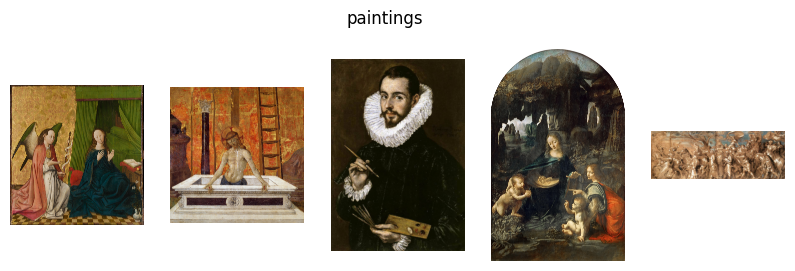

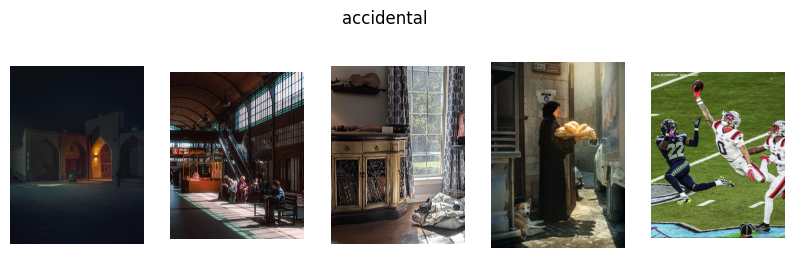

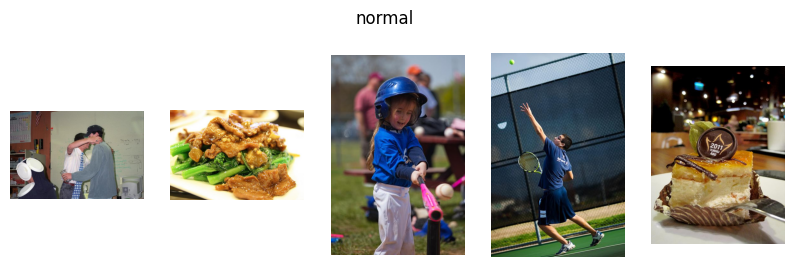

In [ ]:
def show_samples(df, label, n=5):
    subset = df[df["label"] == label].sample(n)

    plt.figure(figsize=(10,3))
    for i, row in enumerate(subset.itertuples()):
        img = Image.open(row.path)
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(label)
    plt.show()

show_samples(data_df, "paintings")
show_samples(data_df, "accidental")
show_samples(data_df, "normal")

#### Image Size Analysis

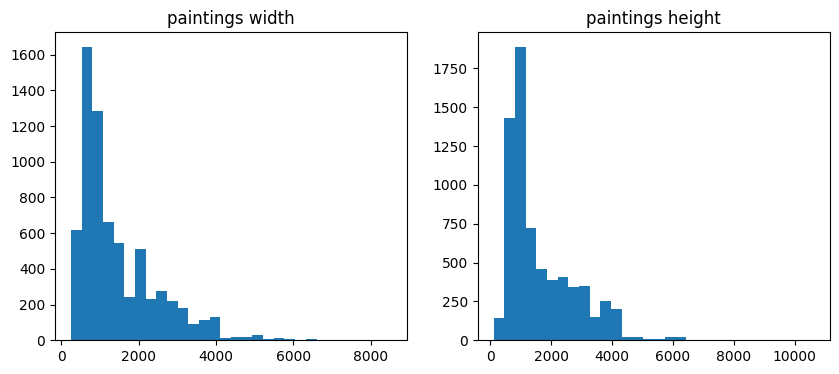

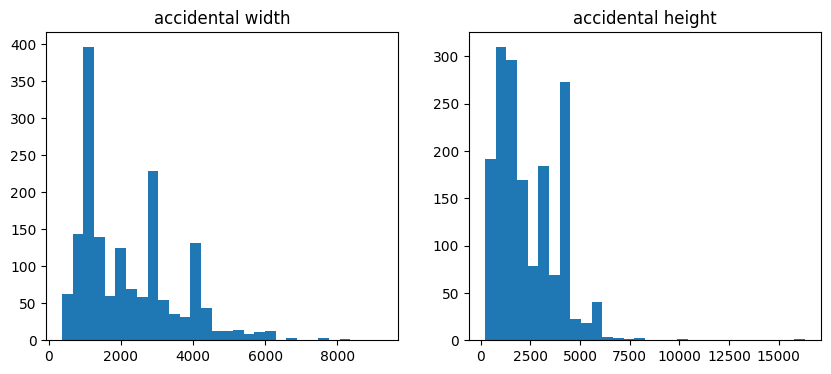

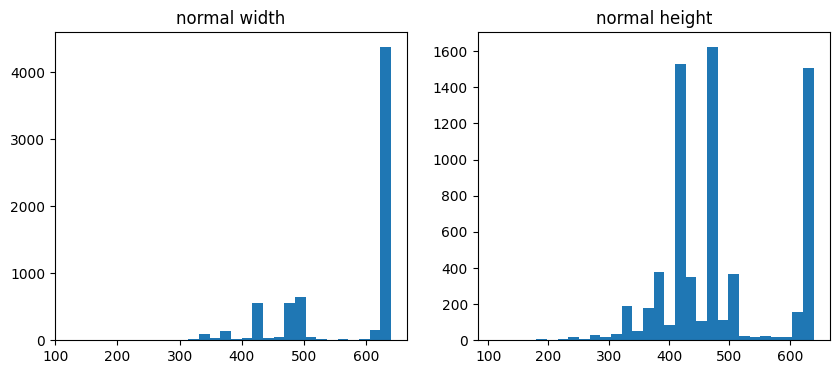

In [ ]:
def plot_size_distribution(df):
    for label in df["label"].unique():
        subset = df[df["label"] == label]

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.hist(subset["width"], bins=30)
        plt.title(f"{label} width")

        plt.subplot(1,2,2)
        plt.hist(subset["height"], bins=30)
        plt.title(f"{label} height")

        plt.show()

plot_size_distribution(data_df)

As expected from the metadata summary, real-world imagery differes in terms of aspect ratio. The width and height distribution showcase that indeed datasets would need to be resized before model training. On the other hand, accidental renaissance photos and painting exhibit similar characteristic.

#### Color, Brightness and Contrast Analysis

In [ ]:
def compute_avg_color(df, size=(64,64)):
    colors = []

    for path in tqdm(df["path"]):
        try:
            img = Image.open(path).convert("RGB").resize(size)
            img = np.array(img)
            colors.append(img.mean(axis=(0,1)))
        except:
            continue

    return np.array(colors)

def compute_brightness_contrast(df):
    brightness = []
    contrast = []

    for path in tqdm(df["path"]):
        try:
            # cconverting to greyscale for brightness/contrast
            img = Image.open(path).convert("L")  
            arr = np.array(img)

            brightness.append(arr.mean())
            contrast.append(arr.std())

        except:
            brightness.append(None)
            contrast.append(None)

    df["brightness"] = brightness
    df["contrast"] = contrast

    return df.dropna()

def plot_color_distribution(df):
    for label in df["label"].unique():
        subset = df[df["label"] == label]
        colors = compute_avg_color(subset)

        plt.hist(colors[:,0], alpha=0.5, label="R", color="red")
        plt.hist(colors[:,1], alpha=0.5, label="G", color="green")
        plt.hist(colors[:,2], alpha=0.5, label="B", color="blue")

        plt.title(f"{label} color distribution")
        plt.legend()
        plt.show()

def plot_brightness_contrast(df):

    for label in df["label"].unique():
        subset = df[df["label"] == label]

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.hist(subset["brightness"], bins=30)
        plt.title(f"{label} brightness")

        plt.subplot(1,2,2)
        plt.hist(subset["contrast"], bins=30)
        plt.title(f"{label} contrast")

        plt.show()

  0%|          | 0/6865 [00:00<?, ?it/s]

100%|██████████| 6865/6865 [05:22<00:00, 21.26it/s] 


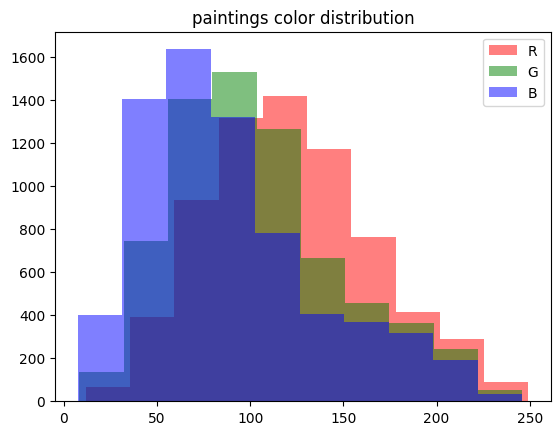

100%|██████████| 1661/1661 [02:03<00:00, 13.41it/s]


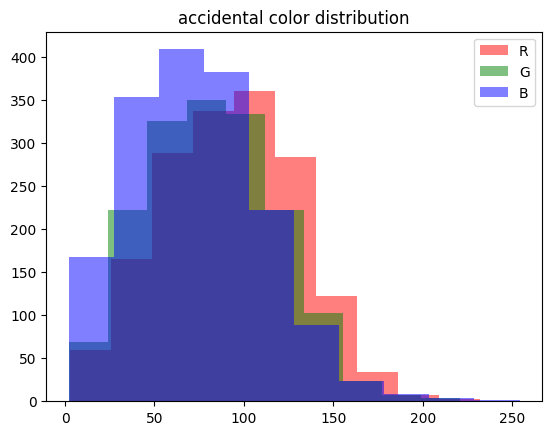

100%|██████████| 6865/6865 [00:34<00:00, 200.25it/s]


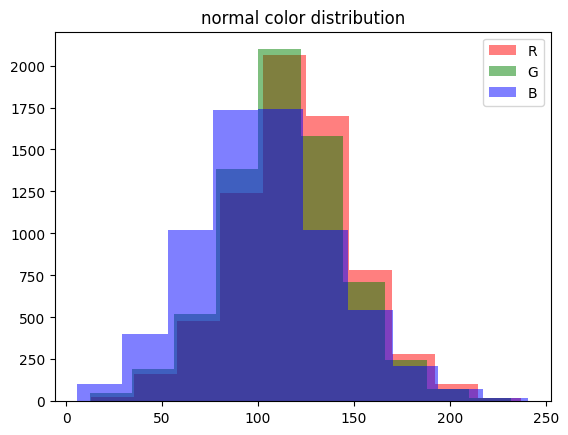

In [ ]:
plot_color_distribution(data_df)

As expected the distribution of vales in each color channel for accidental renaissance and paitings data is similar, thus suggecting it is a feature that influences the overall renaissance-like aesthetic. 

100%|██████████| 15391/15391 [11:47<00:00, 21.76it/s]  


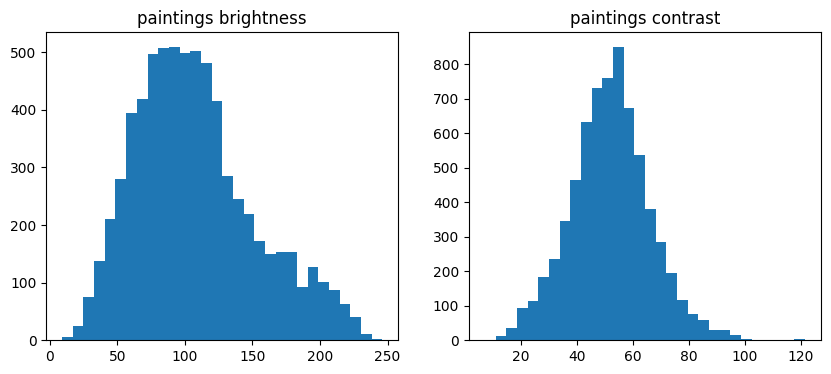

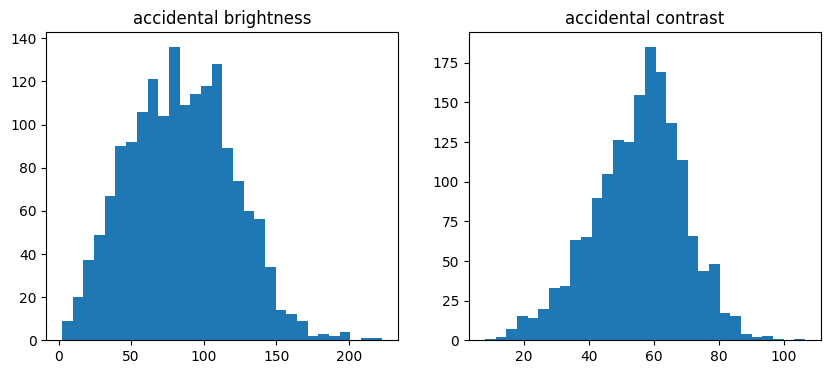

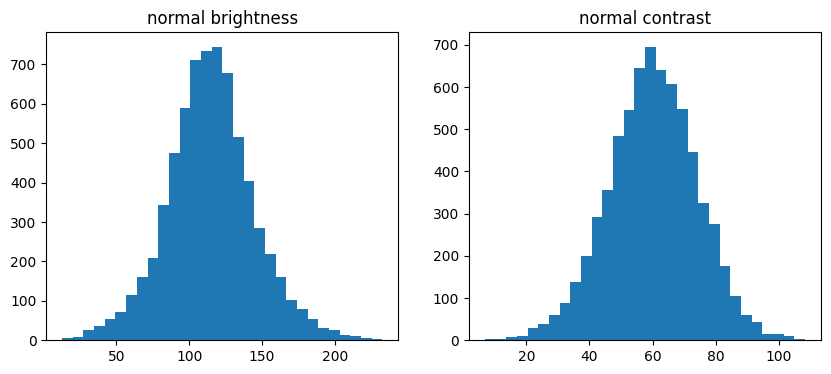

In [ ]:
plot_brightness_contrast(compute_brightness_contrast(data_df))

While the rela-world dataset exhibits a standard Gaussian distribution centered at higher brightness levels, the remiaing two datasets show lean toward lower mean luminance and higher standard deviation (contrast). This statistically confirms that the accidental renaissance domain resambles the lighting and high-contrast aesthetics typical of renaissance paitings domain.

### Edge Density Analysis with Canny Edge Detector

In [ ]:
def compute_edge_density(df, resize=(256,256)):
    densities = []

    for path in tqdm(df["path"]):
        try:

            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                densities.append(None)
                continue

            img = cv2.resize(img, resize)

            # applying Canny
            edges = cv2.Canny(img, threshold1=100, threshold2=200)

            density = edges.sum() / 255 / edges.size
            densities.append(density)

        except:
            densities.append(None)

    df["edge_density"] = densities
    return df.dropna()

def plot_edge_density(df):
    sns.boxplot(x="label", y="edge_density", data=df)
    plt.title("Edge Density by Label")
    plt.show()

  0%|          | 0/15391 [00:00<?, ?it/s]

100%|██████████| 15391/15391 [03:08<00:00, 81.58it/s] 


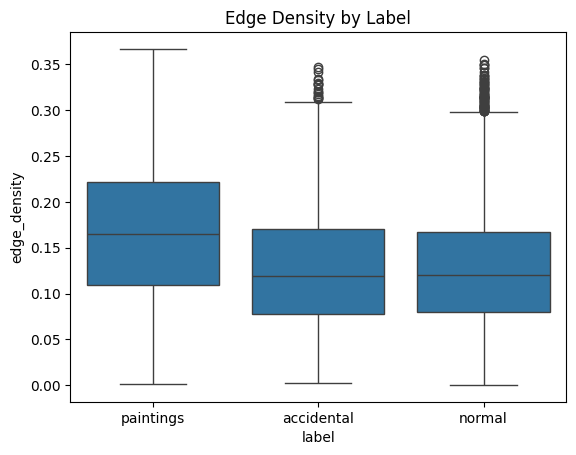

In [ ]:
plot_edge_density(compute_edge_density(data_df))

Despite similarities in brightness/contrast profiles, edge density analysis reveals a texture gap between the real-world and artistic (paintings) domains. The artistic domain exhibits a higher median edge density, likely due to differences such as brushwork, canvas texture, ofetn due to textured background and micro-textures. This suggests that a successful style transfer model must not only adjust global lighting but also take into account higher-frequency textural details.

### Average Image (Compositional Bias)

In [ ]:
def compute_average_image(paths, size=(224, 224)):
    sum_image = None
    count = 0

    for path in tqdm(paths, desc="Computing average"):
        try:
            img = Image.open(path).convert("RGB").resize(size)
            img = np.array(img, dtype=np.float32)

            if sum_image is None:
                sum_image = np.zeros_like(img, dtype=np.float32)

            sum_image += img
            count += 1

        except:
            continue

    if count == 0:
        return None

    avg_image = sum_image / count
    return avg_image.astype(np.uint8)

def compute_domain_averages(df, num_samples=100, size=(224,224)):
    results = {}

    for label in df["label"].unique():
        paths = df[df["label"] == label]["path"].tolist()
        results[label] = compute_average_image(paths, size=size)

    return results

def plot_domain_averages(avg_images):
    n = len(avg_images)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axes = [axes]

    for ax, (label, img) in zip(axes, avg_images.items()):
        if img is not None:
            ax.imshow(img)
            ax.set_title(label, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Computing average: 100%|██████████| 6865/6865 [00:40<00:00, 170.22it/s]


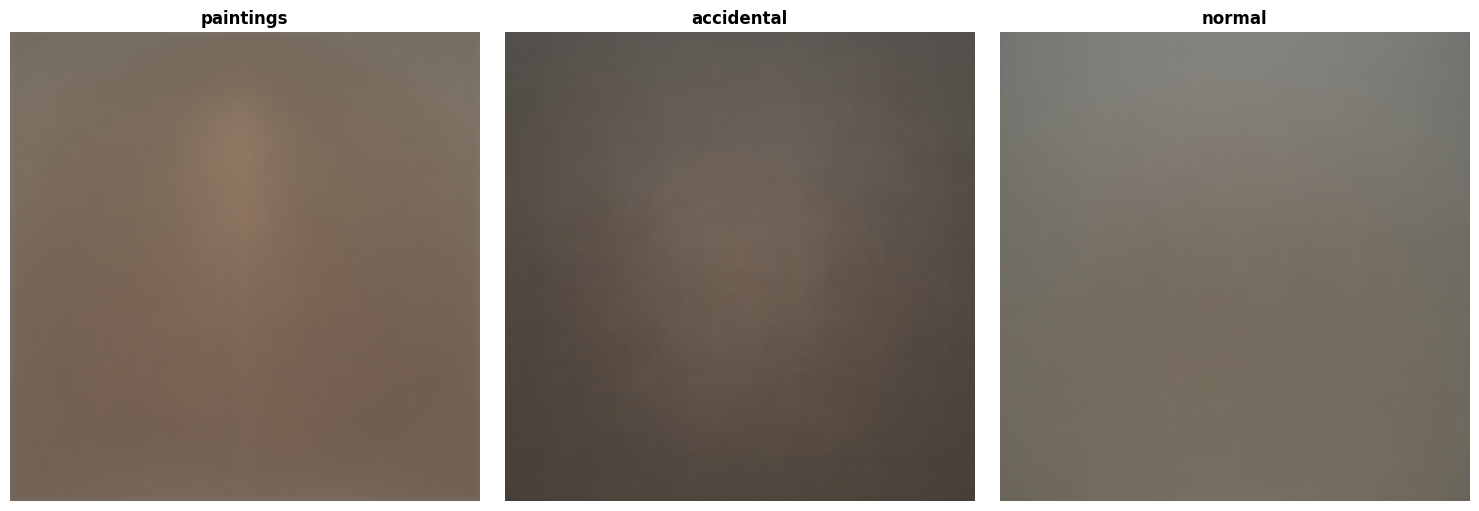

In [ ]:
plot_domain_averages(compute_domain_averages(data_df, num_samples=100, size=(224,224)))

The Mean Image Represenattaion provides an insight into compositional biases within each domain. Both paiting and accidental renaissance imaginery exhibit central luminance (consistent with ttpical for Renaissacne chiaroscuro technique). In contrast, the real-world domain displays more uniform, destaurated distribution, indicating less significant spatial lightning. 

#### Color Palette Analysis (Dominant Colors)

In [ ]:
from sklearn.cluster import KMeans

def get_dominant_colors(pixels, k=5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixels)
    return kmeans.cluster_centers_.astype(np.uint8)

def extract_pixels(paths, num_images=1000, size=(64, 64)):
    pixels = []

    sample_paths = random.sample(paths, min(num_images, len(paths)))

    for path in tqdm(sample_paths, desc="Extracting pixels"):
        try:
            img = Image.open(path).convert("RGB").resize(size)
            arr = np.array(img)

            lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)

            # optional normalization
            # lab = lab.astype(np.float32)
            # lab[:, :, 0] /= 255.0
            # lab[:, :, 1:] -= 128.0

            pixels.append(lab.reshape(-1, 3))

        except:
            continue

    if len(pixels) == 0:
        return None

    return np.vstack(pixels)


def compute_domain_colors(df, k=5):
    results = {}

    for label in df["label"].unique():
        paths = df[df["label"] == label]["path"].tolist()

        pixels = extract_pixels(paths)

        if pixels is None:
            results[label] = None
            continue

        colors = get_dominant_colors(pixels, k=k)
        results[label] = colors

    return results


def lab_to_rgb(colors):
    colors = np.array(colors, dtype=np.uint8).reshape(-1, 1, 3)
    rgb = cv2.cvtColor(colors, cv2.COLOR_LAB2RGB)
    return rgb.reshape(-1, 3)


def create_palette_bar(colors, width=500, height=50, convert_from_lab=True):
    k = len(colors)
    bar = np.zeros((height, width, 3), dtype=np.uint8)

    if convert_from_lab:
        colors = lab_to_rgb(colors)

    step = width // k

    for i, color in enumerate(colors):
        start = i * step
        end = (i + 1) * step if i < k - 1 else width
        bar[:, start:end] = color

    return bar


def plot_palettes(palettes):
    n = len(palettes)
    fig, axes = plt.subplots(n, 1, figsize=(6, 2 * n))

    if n == 1:
        axes = [axes]

    for ax, (label, colors) in zip(axes, palettes.items()):
        if colors is None:
            ax.set_title(f"{label} (no data)")
            ax.axis("off")
            continue

        bar = create_palette_bar(colors)

        ax.imshow(bar)
        ax.set_title(label, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Extracting pixels: 100%|██████████| 1000/1000 [00:04<00:00, 240.44it/s]


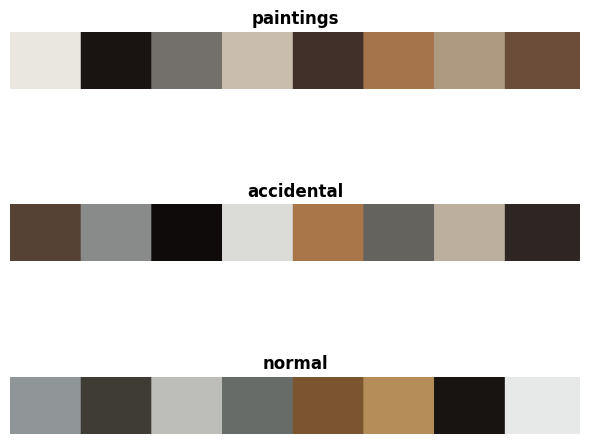

In [ ]:
plot_palettes(compute_domain_colors(data_df, k=8))

All datasources have similar dominat palette but the real-worl dataset has a but more warmth to it.